<a href="https://colab.research.google.com/github/Jinn-M4/Lane-keeping-Assist/blob/main/LKA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lane Keeping Assist (LKA)

# Import & Parameters

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
from IPython.display import Image

dt = 0.1
T_total = 25
time = np.arange(0, T_total, dt)

# vehicle params
L = 2.5
v = 10.0

# pure pursuit params
k = 0.5
L_min = 20.0

# Vehicle Class

In [61]:
class Vehicle:
  def __init__(self, x=0, y=0, yaw=0, v=10):
    self.x = x
    self.y = y
    self.yaw = yaw
    self.v = v

  def update(self, delta, dt):
    self.x += self.v * np.cos(self.yaw) * dt # x = v * cos(heading angle)
    self.y += self.v * np.sin(self.yaw) * dt # y + v * sin(heading angle)
    self.yaw += (self.v / L) * np.tan(delta) * dt # heading angle = v/L * tan(steering angle)


# Path (Lane Center)

In [62]:
def generate_path():
  path_x = np.linspace(0, 400, 800)
  path_y = np.zeros_like(path_x) # 직선 차선
  return path_x, path_y

path_x, path_y = generate_path()

# Pure Pursuit Controller

In [63]:
def find_target(vehicle, path_x, paht_y, Ld, prev_idx):
  distances = np.sqrt((path_x - vehicle.x)**2 + (path_y - vehicle.y)**2)

  idx = prev_idx

  count = 0
  max_step = 5

  while idx < len(path_x) - 1 and distances[idx] < Ld and count < max_step:
    idx += 1
    count += 1

  return path_x[idx], path_y[idx], idx

def pure_pursuit(vehicle ,tx, ty, Ld):
  alpha = np.arctan2(ty - vehicle.y, tx - vehicle.x) - vehicle.yaw
  delta = np.arctan2(2 * L * np.sin(alpha), Ld)
  return delta

# Simulation Loop

In [64]:
vehicle = Vehicle(x=0, y=-30, yaw=0, v=v)

x_hist, y_hist = [], []
target_hist = []
error_hist = []
delta_hist = []

target_idx = 0 # 초기값

for t in time:
  Ld = k * vehicle.v + L_min

  tx, ty, target_idx = find_target(vehicle, path_x, path_y, Ld, target_idx)
  delta = pure_pursuit(vehicle, tx, ty, Ld)

  vehicle.update(delta, dt)

  x_hist.append(vehicle.x)
  y_hist.append(vehicle.y)
  target_hist.append((tx,ty))
  error_hist.append(vehicle.y)
  delta_hist.append(delta)

# Plot

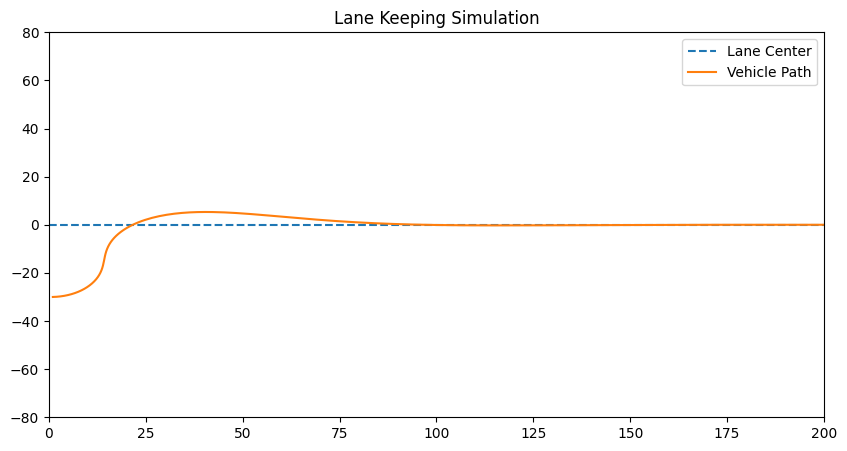

In [65]:
plt.figure(figsize=(10,5))
plt.plot(path_x, path_y, '--', label="Lane Center")
plt.plot(x_hist, y_hist, label="Vehicle Path")
plt.legend()
plt.title("Lane Keeping Simulation")

plt.xlim(0,200)
plt.ylim(-80,80)
plt.show()


# Animation

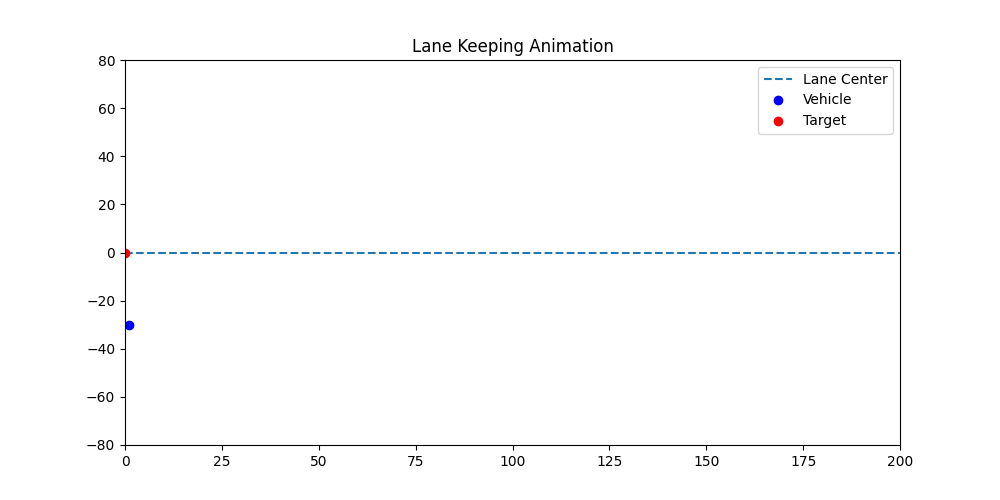

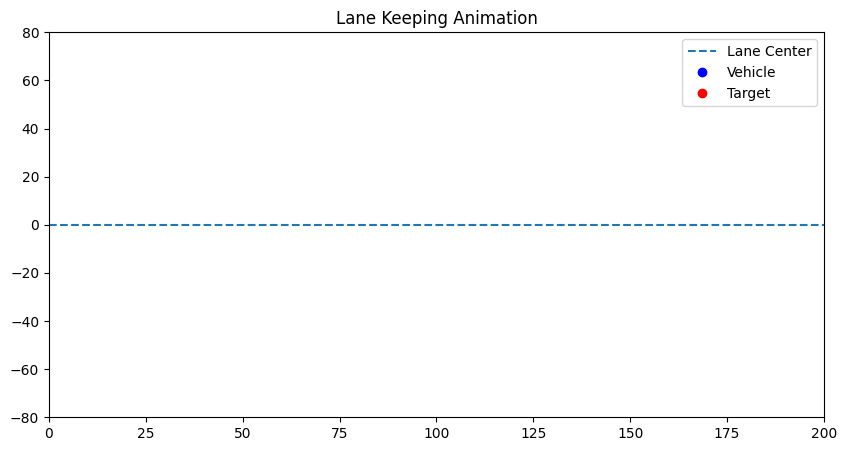

In [66]:
fig, ax = plt.subplots(figsize=(10,5))

# lane
ax.plot(path_x, path_y, '--', label="Lane Center")

# vehicle & target
vehicle_dot, = ax.plot([], [], 'bo', label="Vehicle")
target_dot, = ax.plot([], [], 'ro', label="Target")

# 보기 좋게 설정
ax.set_xlim(0, 200)
ax.set_ylim(-80, 80)
ax.set_title("Lane Keeping Animation")
ax.legend()

def update(frame):
    # vehicle 위치
    vehicle_dot.set_data([x_hist[frame]], [y_hist[frame]])

    # target point
    tx, ty = target_hist[frame]
    target_dot.set_data([tx], [ty])

    return vehicle_dot, target_dot

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(x_hist),
    interval=50,
    blit=True
)

ani.save("lka_simulation.gif", writer=PillowWriter(fps=20))

Image(filename="lka_simulation.gif")